<a href="https://colab.research.google.com/github/huamanchristian44/LAB-16/blob/develop/Laboratorio_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scorecardpy

In [ ]:
#Importando librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scorecardpy as sc
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Columnas según el dataset
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

In [ ]:
# Cargar el CSV
df = pd.read_csv('/content/drive/MyDrive/adult.csv',names=columns)

In [ ]:
# Mostrar primeras filas
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
# Revisar valores únicos en target
print(df['income'].unique())

[' <=50K' ' >50K']


In [ ]:
# Reemplazar '?' por NaN
df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)

In [ ]:
# Mostrar cantidad de datos faltantes
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [ ]:
# Imputar categóricas con moda
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-358-725156027.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.iloc[[32531]]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32531,30,Private,33811,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K


In [ ]:
# Mostrar cantidad de datos faltantes
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [ ]:
#Analizando variable 'capital-gain'
df['capital-gain'].unique()

array([ 2174,     0, 14084,  5178,  5013,  2407, 14344, 15024,  7688,
       34095,  4064,  4386,  7298,  1409,  3674,  1055,  3464,  2050,
        2176,   594, 20051,  6849,  4101,  1111,  8614,  3411,  2597,
       25236,  4650,  9386,  2463,  3103, 10605,  2964,  3325,  2580,
        3471,  4865, 99999,  6514,  1471,  2329,  2105,  2885, 25124,
       10520,  2202,  2961, 27828,  6767,  2228,  1506, 13550,  2635,
        5556,  4787,  3781,  3137,  3818,  3942,   914,   401,  2829,
        2977,  4934,  2062,  2354,  5455, 15020,  1424,  3273, 22040,
        4416,  3908, 10566,   991,  4931,  1086,  7430,  6497,   114,
        7896,  2346,  3418,  3432,  2907,  1151,  2414,  2290, 15831,
       41310,  4508,  2538,  3456,  6418,  1848,  3887,  5721,  9562,
        1455,  2036,  1831, 11678,  2936,  2993,  7443,  6360,  1797,
        1173,  4687,  6723,  2009,  6097,  2653,  1639, 18481,  7978,
        2387,  5060])

In [ ]:
#Valores de la variable 'capital-gain'
print(df['capital-gain'].value_counts())

capital-gain
0        29849
15024      347
7688       284
7298       246
99999      159
         ...  
6097         1
1639         1
7978         1
2387         1
5060         1
Name: count, Length: 119, dtype: int64


In [ ]:
#Analizndo la variable 'capital-loss'
df['capital-loss'].unique()

array([   0, 2042, 1408, 1902, 1573, 1887, 1719, 1762, 1564, 2179, 1816,
       1980, 1977, 1876, 1340, 2206, 1741, 1485, 2339, 2415, 1380, 1721,
       2051, 2377, 1669, 2352, 1672,  653, 2392, 1504, 2001, 1590, 1651,
       1628, 1848, 1740, 2002, 1579, 2258, 1602,  419, 2547, 2174, 2205,
       1726, 2444, 1138, 2238,  625,  213, 1539,  880, 1668, 1092, 1594,
       3004, 2231, 1844,  810, 2824, 2559, 2057, 1974,  974, 2149, 1825,
       1735, 1258, 2129, 2603, 2282,  323, 4356, 2246, 1617, 1648, 2489,
       3770, 1755, 3683, 2267, 2080, 2457,  155, 3900, 2201, 1944, 2467,
       2163, 2754, 2472, 1411])

In [ ]:
#Valores de la variable 'capital-loss'
print(df['capital-loss'].value_counts())

capital-loss
0       31042
1902      202
1977      168
1887      159
1485       51
        ...  
2201        1
2467        1
2163        1
2472        1
1411        1
Name: count, Length: 92, dtype: int64


In [ ]:
#Tratamiento de outliers
from sklearn.ensemble import IsolationForest

X_num = df[['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']]

iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(X_num)

# -1 son outliers, 1 son normales
df['outlier'] = outliers
df = df[df['outlier'] != -1].drop('outlier', axis=1)

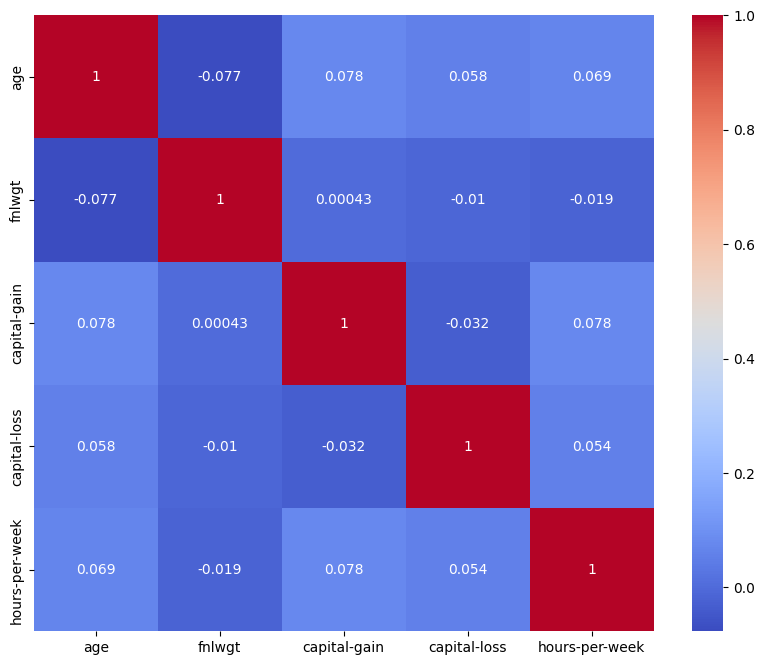

In [ ]:
#Correlación entre variables predictoras
corr = X_num.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#Valores de la variable 'income'
print(df['income'].unique())

[' <=50K' ' >50K']


In [ ]:
#Eliminando espacios
df['income'] = df['income'].str.strip()

In [ ]:
#Indexando la variable binaria
df['income'] = df['income'].map({'<=50K':0, '>50K':1})

In [ ]:
#Verificando la indexación
df['income'].head(10)

,income
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,1
8,1
9,1


In [ ]:
# Separar target antes de transformar
y = df['income']

# Aplicar WOE solo a las X
X_woe = sc.woebin_ply(df2.drop('income', axis=1), bins)

# Unir con el target original
X_woe['income'] = y

[INFO] converting into woe values ...


In [ ]:
iv = sc.iv(df, y='income')

In [ ]:
#Ordenando en forma descendente
iv = iv.sort_values(by='info_value', ascending=False)
print(iv)

          variable  info_value
10    relationship    1.540341
5   marital-status    1.348291
7     capital-gain    1.234694
9              age    1.196297
11   education-num    0.715284
3        education    0.715284
1       occupation    0.636164
0   hours-per-week    0.500881
12    capital-loss    0.494499
2              sex    0.302682
13          fnlwgt    0.276722
4        workclass    0.122799
6   native-country    0.079572
8             race    0.068784


In [ ]:
# Seleccionar variables con IV > 0.1
selected_features = iv[iv['info_value'] > 0.1]['variable'].tolist()
print("Variables seleccionadas:", selected_features)

Variables seleccionadas: ['relationship', 'marital-status', 'capital-gain', 'age', 'education-num', 'education', 'occupation', 'hours-per-week', 'capital-loss', 'sex', 'fnlwgt', 'workclass']


In [ ]:
#Hacer binning solo de esas variables
df_subset = df[selected_features + ['income']]
bins = sc.woebin(df_subset, y='income', positive=1)

[INFO] creating woe binning ...


/usr/local/lib/python3.11/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.11/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.11/dist-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is

In [ ]:
#Transformar a WOE solo las X
X_woe = sc.woebin_ply(df_subset.drop('income', axis=1), bins)

[INFO] converting into woe values ...


In [ ]:
#Añadir el target
X_woe['income'] = df_subset['income']

In [ ]:
#Trabajando con un nuevo dataset
df2 = df.drop(columns=['race', 'native-country'])
df2.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,0


In [ ]:
#Extrayendo variables numéricas
num_cols = df2.select_dtypes(include=np.number).columns.tolist()
print("Variables numéricas:", num_cols)

Variables numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


In [ ]:
# Escalar solo numéricas
scaler = StandardScaler()
df2[num_cols] = scaler.fit_transform(df2[num_cols])

In [ ]:
# Variables categóricas a dummies
df3 = pd.get_dummies(df2, drop_first=True)
df3.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,sex_ Male
0,0.038810,-1.070884,1.147181,0.649295,-0.210091,-0.030420,-0.554666,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,0.850121,-1.015242,1.147181,-0.232111,-0.210091,-2.246908,-0.554666,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,-0.034946,0.255383,-0.414943,-0.232111,-0.210091,-0.030420,-0.554666,False,False,True,...,False,False,False,False,True,False,False,False,False,True
3,1.071388,0.438533,-1.196005,-0.232111,-0.210091,-0.030420,-0.554666,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,-0.772501,1.434102,1.147181,-0.232111,-0.210091,-0.030420,-0.554666,False,False,True,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
#Separando datos de entrenamiento y de prueba
X = df3.drop('income', axis=1)  # Suponiendo que dummificó income
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Balancear con SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)